In [1]:
import os 
os.environ["OMP_NUM_THREADS"] = "50"

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(["science"])

plt.rcParams.update({'font.size': 12})
plt.rcParams.update({
    "text.usetex": True,        
    "font.family": "serif",     
    "font.serif": ["Times"],
    "figure.dpi": 300,          
    "axes.grid": True,          
    "grid.linestyle": "--",     
})

In [3]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from multiprocessing import Pool
import time
import torch
from scipy.ndimage import gaussian_filter
from ds_utils import  *
from ps_utils import  *

In [4]:
DATA_DIR = Path("/pscratch/sd/k/kp22/deft/")

# Flat sky

In [75]:
RES = 256
STEP_SIZE = 6. 
ANG_X = 6. 
ANG_Y = 6. 
flatskymapparams = [RES, RES, 60.*ANG_X/RES, 60.*ANG_X/RES] #Needs pixelres to be in arcmin
nx,ny,dx,dy = flatskymapparams
dx_rad = np.radians(dx/60.)
dy_rad = np.radians(dy/60.)
lx, ly = get_lxly(flatskymapparams)
ell_grid = np.sqrt(lx**2 + ly**2)
ptsrc=2

In [6]:
n_samples = 801

In [7]:
def bandpass_filter(map_i, l_c, delta_l):
    """ Filter the map in Fourier space to only include a band around l_c with width delta_l """
    fft_map = fft2(map_i)
    mask = (ell_grid >= (l_c - delta_l/2)) & (ell_grid <= (l_c + delta_l/2))
    fft_map *= mask
    return ifft2(fft_map).real

In [43]:
def compute_statistics(map_i):
    """ Compute the variance, skewness, and kurtosis of the map """
    mean_subtracted_map = map_i - np.mean(map_i)
    S2 = np.mean(mean_subtracted_map**2)
    S3 = np.mean(mean_subtracted_map**3) 
    S4 = np.mean(mean_subtracted_map**4) - 3 * S2**2
    return S2, S3, S4

In [44]:
def compute_statistics_per_band(maps, band_centers, delta_l,apo=True):
    moments_data = np.empty((len(maps), len(band_centers), 3))
    for i in range(len(maps)): 
        if i%200 == 0: print(f"{i}/{len(maps)}")
        map_data = maps[i, :, :, 0]
        for j,center in enumerate(band_centers):            
            filtered_map = bandpass_filter(map_data, center, delta_l)
            S2, S3, S4 = compute_statistics(filtered_map)

            moments_data[i][j][0] = S2
            moments_data[i][j][1] = S3
            moments_data[i][j][2] = S4
            
    return moments_data

In [45]:
lmin = 300
lmax = 6000
delta_l = 720
bandpass_edges = np.arange(lmin, lmax, delta_l)
bandpass_centers = (bandpass_edges[:-1] + bandpass_edges[1:]) // 2

In [49]:
RES = 256
STEP_SIZE = 6. * u.deg
ANG_X = 6. * u.deg
ANG_Y = 6. * u.deg
flatskymapparams = [RES, RES, 60.*ANG_X.value/RES, 60.*ANG_Y.value/RES] #Code requires pixelres to be in arcmin

In [50]:
fpath_cib = f"data/low_pass/{ptsrc}mJy/cut_maps_RES_256_ANG_X_6.0 deg_2mJy_lp.npy"
fpath_tsz = f"data/low_pass/{ptsrc}mJy/cut_maps_RES_256_ANG_X_6.0 deg_2mJy_lp_tsz3.npy"

cib_maps = np.load(fpath_cib)  # (N, H, W, 1)
tsz_maps = np.load(fpath_tsz)  # (N, H, W, 1)

cut_maps = np.concatenate([cib_maps, tsz_maps], axis=-1)
num_samples = len(cut_maps)

In [52]:
cut_maps.shape

(1041, 256, 256, 2)

In [53]:
num_train = int(0.8 * num_samples)
rng = np.random.default_rng(seed=42)
indices = rng.permutation(num_samples)
train_indices = indices[:num_train]
test_indices = indices[num_train:]
training_images = cut_maps[train_indices]
testing_images = cut_maps[test_indices]

In [54]:
training_images.shape

(832, 256, 256, 2)

In [55]:
sum_maps =  np.sum(training_images[:n_samples], axis=-1, keepdims=True)

In [76]:
def apply_ptsrc_mask(map):
    inds = np.where(abs(map)>np.mean(map)+3*np.std(map))
    map[inds]=0

In [56]:
moments_data_train = compute_statistics_per_band(sum_maps[:n_samples], bandpass_centers,delta_l)

0/801
200/801
400/801
600/801
800/801


In [57]:
np.save("data/low_pass/2mJy/moments_train_2mJy_deltaell_720_200rlz_6x6_lp_joint3_sum.npy",moments_data_train)

In [58]:
fpath_cib = f"data/low_pass/{ptsrc}mJy/cut_maps_RES_256_ANG_X_6.0 deg_2mJy_lp_gaussian_cib_joint3.npy"
fpath_tsz = f"data/low_pass/{ptsrc}mJy/cut_maps_RES_256_ANG_X_6.0 deg_2mJy_lp_gaussian_tsz_joint3.npy"

cib_maps = np.load(fpath_cib)  # (N, H, W, 1)
tsz_maps = np.load(fpath_tsz)  # (N, H, W, 1)

cut_maps = np.concatenate([cib_maps, tsz_maps], axis=-1)
num_samples = len(cut_maps)

In [59]:
sum_maps =  np.sum(cut_maps[:n_samples], axis=-1, keepdims=True)
sum_maps.shape

(801, 256, 256, 1)

In [60]:
moments_data_gaussian = compute_statistics_per_band(sum_maps[:n_samples], bandpass_centers,delta_l)

0/801
200/801
400/801
600/801
800/801


In [61]:
np.save("data/low_pass/2mJy/moments_gaussian_2mJy_deltaell_720_200rlz_6x6_lp_joint3_sum.npy",moments_data_gaussian)

In [62]:
#all_samples = np.load("data/low_pass/2mJy/new_samples_12_cib_tsz_2mJy_zero_norm_6x6_w_au_lp.npy")
all_samples = np.load("data/low_pass/2mJy/new_samples_16_cib_tsz3_2mJy_zero_norm_6x6_w_au_lp.npy")

In [63]:
all_samples[:,0,] *= 110.732285
all_samples[:,0,] = ((all_samples[:,0,] - np.mean(all_samples[:,0,]))*(np.std(cut_maps[:,:,:,0])/np.std(all_samples[:,0,]))) + np.mean(all_samples[:,0,])

In [64]:
all_samples[:,1,] *= 158.31772#102.28776
all_samples[:,1,] -= 158.31772#102.28776
all_samples[:,1,] = ((all_samples[:,1,] - np.mean(all_samples[:,1,]))*(np.std(cut_maps[:,:,:,1])/np.std(all_samples[:,1,]))) + np.mean(all_samples[:,1,])

In [65]:
all_samples = all_samples.transpose(0, 2, 3, 1)

In [66]:
all_samples.shape

(960, 256, 256, 2)

In [67]:
sum_maps =  np.sum(all_samples[:n_samples], axis=-1, keepdims=True)
sum_maps.shape

(801, 256, 256, 1)

In [68]:
moments_samples = compute_statistics_per_band(sum_maps[:n_samples], bandpass_centers,delta_l)

0/801
200/801
400/801
600/801
800/801


In [69]:
np.save("data/low_pass/2mJy/moments_samples_2mJy_deltaell_720_200rlz_6x6_lp_curve_joint3_sum.npy",moments_samples)

In [70]:
def load_moments(filename,max_lines=-1):
    moments_data = np.load(filename)[:max_lines]
    moments={}
    moments["variances"] = [m/bandpass_centers for m in moments_data[:,:,0]]
    moments["skewnesses"] = [m/bandpass_centers for m in moments_data[:,:,1]]
    moments["kurtoses"] = [m/bandpass_centers**2 for m in moments_data[:,:,2]]
    return moments

In [71]:
moments_data_train = load_moments("data/low_pass/2mJy/moments_train_2mJy_deltaell_720_200rlz_6x6_lp_joint3_sum.npy")
moments_samples = load_moments("data/low_pass/2mJy/moments_samples_2mJy_deltaell_720_200rlz_6x6_lp_curve_joint3_sum.npy")
moments_data_gaussian = load_moments("data/low_pass/2mJy/moments_gaussian_2mJy_deltaell_720_200rlz_6x6_lp_joint3_sum.npy")

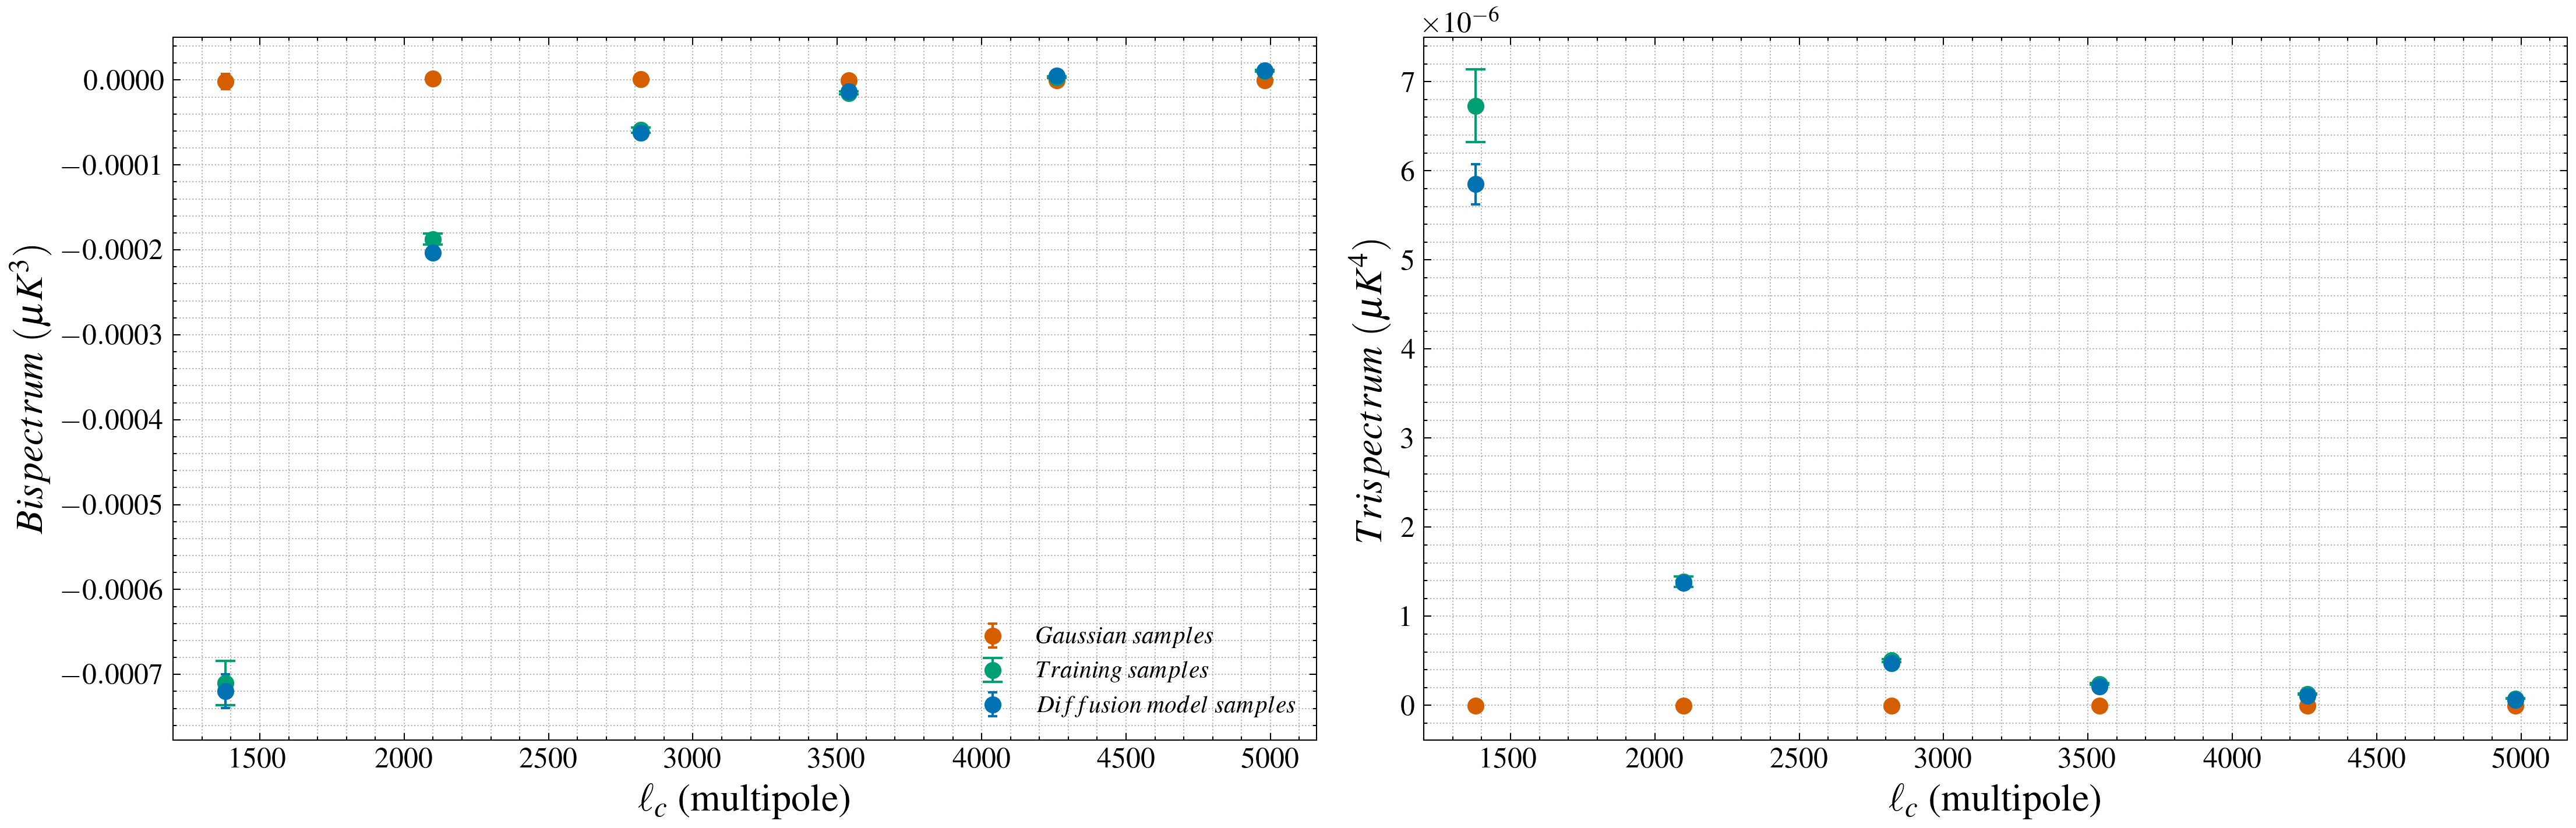

In [74]:
exclude_n = 1
fsval = 16
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].errorbar(bandpass_centers[exclude_n:], 
                 np.mean(moments_data_gaussian["skewnesses"], axis=0)[exclude_n:], 
                 yerr=np.std(moments_data_gaussian["skewnesses"], axis=0)[exclude_n:]/np.sqrt(200),
                 fmt='o', capsize=2, color="#D55E00", label=r"$Gaussian\ samples$")
axes[0].errorbar(bandpass_centers[exclude_n:], 
                 np.mean(moments_data_train["skewnesses"], axis=0)[exclude_n:], 
                 yerr=np.std(moments_data_train["skewnesses"], axis=0)[exclude_n:]/np.sqrt(200),
                 fmt='o', capsize=4, color="#009E73", label=r"$Training\ samples$")
axes[0].errorbar(bandpass_centers[exclude_n:], 
                 np.mean(moments_samples["skewnesses"], axis=0)[exclude_n:], 
                 yerr=np.std(moments_samples["skewnesses"], axis=0)[exclude_n:]/np.sqrt(200),
                 fmt='o', capsize=2, color="#0072B2", label=r"$Diffusion\ model\ samples$")
axes[0].set_xlabel(r'$\ell_c$ (multipole)', fontsize=fsval)
axes[0].set_ylabel(r'$Bispectrum\ (\mu K^3)$', fontsize=fsval)
axes[0].grid(True, which='both', ls=':', lw=0.5)
axes[0].legend(fontsize=10)

axes[1].errorbar(bandpass_centers[exclude_n:], 
                 np.mean(moments_data_gaussian["kurtoses"], axis=0)[exclude_n:], 
                 yerr=np.std(moments_data_gaussian["kurtoses"], axis=0)[exclude_n:]/np.sqrt(200),
                 fmt='o', capsize=2, color="#D55E00", label=r"$Gaussian\ samples$")
axes[1].errorbar(bandpass_centers[exclude_n:], 
                 np.mean(moments_data_train["kurtoses"], axis=0)[exclude_n:], 
                 yerr=np.std(moments_data_train["kurtoses"], axis=0)[exclude_n:]/np.sqrt(200),
                 fmt='o', capsize=4, color="#009E73", label=r"$Training\ samples$")
axes[1].errorbar(bandpass_centers[exclude_n:], 
                 np.mean(moments_samples["kurtoses"], axis=0)[exclude_n:], 
                 yerr=np.std(moments_samples["kurtoses"], axis=0)[exclude_n:]/np.sqrt(200),
                 fmt='o', capsize=2, color="#0072B2", label=r"$Diffusion\ model\ samples$")
axes[1].set_xlabel(r'$\ell_c$ (multipole)', fontsize=fsval)
axes[1].set_ylabel(r'$Trispectrum\ (\mu K^4)$', fontsize=fsval)
# axes[1].set_xscale('log')
axes[1].grid(True, which='both', ls=':', lw=0.5)
#axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig("/global/homes/k/kp22/ddpm_paper/figures/moments_joint_cib_tsz3_sum.pdf", dpi=200, bbox_inches="tight")
plt.savefig("/global/homes/k/kp22/ddpm_paper/figures/moments_joint_cib_tsz3_sum.png", dpi=200, bbox_inches="tight")
plt.show()